# SimpleMincClassifier (SMC)


---





## Introduction

This is my first CNN model,it uses the MINC-2500 dataset to classify different images depending on what type of material they have, each image from the dataset contains exactly one label

This model was done in part followin [Rob Mulla's tutorial on how to build a pytorch model](https://www.youtube.com/watch?v=tHL5STNJKag). Altough it deviates on a couple of things (I haven't used the same dataset or base model given by pyTorch)

### Why ResNet?
While I watched the video I thought it'd be better to deviate from it a bit to find conclusions on my own.

I was also not aware of how the model proposed in the video worked, but I did read ResNet's paper
### Why material classification?
A while ago a friend of mine was challenged to find the type of material that different online products had, at that time I thought it'd be impossible to classify everything.

Putting aside personals reasons,material classification can be a challenge due to different materials sharing simmilar patterns

##Dataset Download
We download the dataset from kagglehub and save it to our google drive.

the dataset that we'll be using is called MINC-2500, It's a material recognition dataset

In [ ]:
import os
import kagglehub
from google.colab import drive

cache_dir = "/content/kagglehub_cache"
os.makedirs(cache_dir, exist_ok=True)
os.environ['KAGGLEHUB_CACHE'] = cache_dir

path = kagglehub.dataset_download("liewyousheng/minc2500")
print("Path to dataset files (Local): ", path)


100%|██████████| 2.10G/2.10G [00:34<00:00, 65.1MB/s]

Extracting files...


Path to dataset files (Local):  /content/kagglehub_cache/datasets/liewyousheng/minc2500/versions/1


##Library Setup

In [ ]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision.datasets import ImageFolder
import timm
from torch.optim.lr_scheduler import ReduceLROnPlateau

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from  tqdm.notebook import tqdm


## DataSet Setup
We create a custom dataset class and split the data into training, validation, and test sets.

In [ ]:
class MincDataset(Dataset):
  def __init__(self,data_dir,transform=None):
    self.data = ImageFolder(root=data_dir,transform=transform)
  def __len__(self):
    return len(self.data)
  def __getitem__(self,idx):
    return self.data[idx]
  @property
  def classes(self):
    return self.data.classes

In [ ]:
# Update image_path to use the path returned by kagglehub
image_path = os.path.join(path, "minc-2500", "images")
dataset = MincDataset(data_dir=image_path)
print(f"Dataset initialized at: {image_path}")

Dataset initialized at: /content/kagglehub_cache/datasets/liewyousheng/minc2500/versions/1/minc-2500/images


In [ ]:
len(dataset)

57500

In [ ]:
dataset[10]

(<PIL.Image.Image image mode=RGB size=362x362>, 0)

Below we create a dictionary that associates a number with a label

In [ ]:
data_dir = image_path
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'brick', 1: 'carpet', 2: 'ceramic', 3: 'fabric', 4: 'foliage', 5: 'food', 6: 'glass', 7: 'hair', 8: 'leather', 9: 'metal', 10: 'mirror', 11: 'other', 12: 'painted', 13: 'paper', 14: 'plastic', 15: 'polishedstone', 16: 'skin', 17: 'sky', 18: 'stone', 19: 'tile', 20: 'wallpaper', 21: 'water', 22: 'wood'}


We resize each of the images of thhe dataset into a 224x224
and convert them to a tensor,I'm using ImageNet's mean and std for normalization

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224,scale=(0.08,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
dataset = MincDataset(data_dir=image_path, transform=train_transform)

In [ ]:
image,label = dataset[0]
print(label)
print(target_to_class[label])
image

0
brick


tensor([[[-1.8439, -1.8439, -1.8439,  ..., -1.8439, -1.8439, -1.8439],
         [-1.8439, -1.8439, -1.8439,  ..., -1.8439, -1.8439, -1.8439],
         [-1.8439, -1.8439, -1.8439,  ..., -1.8439, -1.8439, -1.8439],
         ...,
         [-1.8439, -1.8439, -1.8439,  ..., -1.8439, -1.8439, -1.8439],
         [-1.8439, -1.8439, -1.8439,  ..., -1.8439, -1.8439, -1.8439],
         [-1.8439, -1.8439, -1.8439,  ..., -1.8439, -1.8439, -1.8439]],

        [[-1.7556, -1.7556, -1.7556,  ..., -1.7556, -1.7556, -1.7556],
         [-1.7556, -1.7556, -1.7556,  ..., -1.7556, -1.7556, -1.7556],
         [-1.7556, -1.7556, -1.7556,  ..., -1.7556, -1.7556, -1.7556],
         ...,
         [-1.7556, -1.7556, -1.7556,  ..., -1.7556, -1.7556, -1.7556],
         [-1.7556, -1.7556, -1.7556,  ..., -1.7556, -1.7556, -1.7556],
         [-1.7556, -1.7556, -1.7556,  ..., -1.7556, -1.7556, -1.7556]],

        [[-1.5256, -1.5256, -1.5256,  ..., -1.5256, -1.5256, -1.5256],
         [-1.5256, -1.5256, -1.5256,  ..., -1

## Dataloader setup

In [ ]:
dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

## Pytorch model setup  
We're going to use a predefined architecture given by pyTorch to classify the images

In [ ]:
class SimpleMincClassifier(nn.Module):
  def __init__(self, num_classes=23, dropout_p=0.3):
    super().__init__()
    self.base_model = timm.create_model('resnet34', pretrained=True, num_classes=num_classes, drop_rate=dropout_p)

  def forward(self, x):
    return self.base_model(x)

In [ ]:
model = SimpleMincClassifier(num_classes=23)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
for images,labels in dataloader:
  output=model(images)
  print(output.shape)
  break

torch.Size([32, 23])


## Training Loop
I kept the learning rate constant which is something to be improved upon to learn which one is best

I didn't know how to split the dataset into training,validation,test so I decided to follow the [common approach](https://DataLoader(val_dataset,batch_size=32,shuffle=True))



In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.00005)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4,
                              threshold=0.0001)

In [ ]:
import copy

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder(image_path, transform=train_transform)
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

val_dataset.dataset = copy.copy(dataset)
val_dataset.dataset.transform = val_transform

test_dataset.dataset = copy.copy(dataset)
test_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SimpleMincClassifier(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act1): ReLU(inplace=True)
        (aa): Identity()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act2): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1

In [ ]:
num_epochs = 30  # Increased number of epochs
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_state = None # To store the state of the best model
not_improving = 0 # Initialize not_improving counter for early stopping
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMincClassifier(num_classes=23, dropout_p=0.3)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)
criterion = nn.CrossEntropyLoss()

print(f"Starting training on {device} with Dropout enabled...")

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1} Training'):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * images.size(0)

  train_loss = running_loss / len(train_loader.dataset)
  train_losses.append(train_loss)

  model.eval()
  running_val_loss = 0.0
  with torch.no_grad():
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1} Validation'):
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      running_val_loss += loss.item() * images.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    # Early stopping logic
    if val_loss < best_val_loss:
      not_improving = 0
      best_val_loss = val_loss
      best_model_state = model.state_dict() # Save the best model state
      not_improving = 0 # Reset counter if improvement
      print(f"Validation loss improved. Saving model state.")
    else:
      not_improving +=1
      if not_improving ==8:
        print(f"Validation loss did not improve. Stopping early.")
        break

  print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

# Load the best model state before checking accuracy
if best_model_state:
  model.load_state_dict(best_model_state)
  print("Loaded best model state for evaluation.")

Starting training on cuda with Dropout enabled...


Epoch 1 Training:   0%|          | 0/1258 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Validation loss improved. Saving model state.
Epoch 1/30 - Train Loss: 1.8482 - Val Loss: 1.2110


Epoch 2 Training:   0%|          | 0/1258 [00:00<?, ?it/s]

...

Validation loss improved. Saving model state.
Epoch 6/30 - Train Loss: 1.3772 - Val Loss: 1.0445


Epoch 7 Training:   0%|          | 0/1258 [00:00<?, ?it/s]

Epoch 7 Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Epoch 7/30 - Train Loss: 1.3710 - Val Loss: 1.0728


Epoch 8 Training:   0%|          | 0/1258 [00:00<?, ?it/s]

## Analysis


In [ ]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

In [ ]:
def check_accuracy(loader, model, device):
    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Checking accuracy"):
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train()
    return float(num_correct) / num_samples

model.load_state_dict(best_model_state)
val_acc = check_accuracy(val_loader, model, device)
test_acc = check_accuracy(test_loader, model, device)
print(f"Current Validation Accuracy: {val_acc*100:.2f}%")
print(f"Current Test Accuracy: {test_acc*100:.2f}%")

##Conclusions
I've realised a couple of things here, I had a training slowdown because I was downloading to my drive and I had a sever bottleneck.

After speeding things up to a reasonable level I realised that while my training loss was down, my validation loss remained the same and started to spike at the last epoch (Graph below)



# 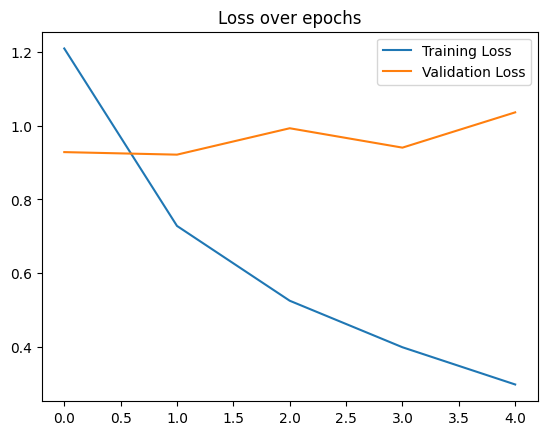

So I decided to add regularisation and data augmentation to see if that would solve it.

I also realized that the ammount of epochs was too low (five) in respect to the dataset, but increasing the ammount of epochs would mean more training time and I don't have more free compute time  

I thought about increasing the batch size but that could potentially worsen my overfitting so I've decided to keep it as is

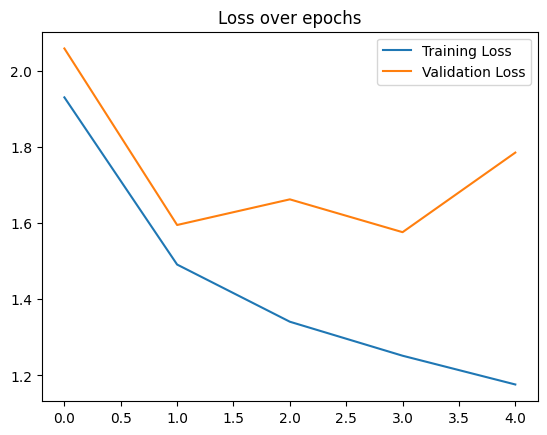

As shown above the training loss and the validation loss is significantly worse off. There still was a significant reduction in the distance between them at the expense of a greater loss.

The validation accuracy is now 53.63%


Considering there's still overfitting I dropped learning rate down to 5e-5,changed the training transform to include RandomResizeCrops,added weight decay and early stopping (stops if the validation loss decreased for one concurrent epoch) to fix the overfitting the model had


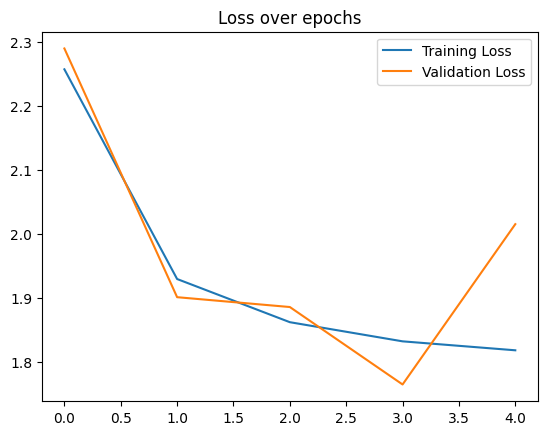

Now the training loss and validation loss seem to go hand in hand which is promising, but we still need to reduce the loss of the best model state and increase accuracy (it has now dropped to 42.7%)

I've increased the epochs to 30 and added an scheduler(lronplateau) and increased the early stopping to eight

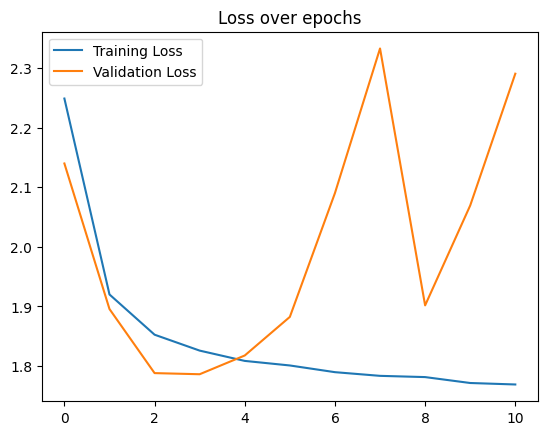

I've realised that I had my train_transform ordered in the wrong way, I'll fix that and see if it works now

it seems like around epoch 4 the model starts to diverge

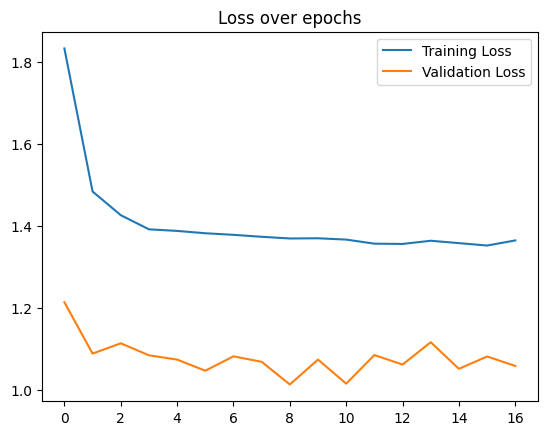

Both training and validation loss went down,Current Validation Accuracy: 67.83% which is a significant performance improvement
